# S3 TSMOM — Phase 1: Baselines & Gate K1

**Purpose.** Run the two pre-registered baseline definitions (charter §4) through the full CPCV gauntlet
at the $1M mandate with real IBKR costs, and answer one question: **does plain trend-following on this
basket still pay after costs, across many market eras?**

**Gate K1 (charter §8).** Best baseline net P5_Sharpe ≤ 0 across the 66 paths → the strategy class is dead
at this cost structure and universe. Stop. No ML resurrection attempts.

**Rules of this notebook.**
- The terminal holdout is registered ONCE here and enforced automatically by the optimizer.
- The baselines are FIXED definitions — no parameter search. The only sweep is the cost-sensitivity
  battery (slippage), which asks how fragile the answer is, not what the best parameter is.
- Nothing computed here is used to change the charter's feature inventory or hyperparameter grid.


In [2]:
import sys, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# --- Locate the repo root robustly (VS Code, JupyterLab and Docker all start
# kernels in different working directories). Walk UP from the working directory
# AND from this notebook's own location; the repo root is the first folder that
# actually contains src/config.py. No guessing from folder names.
def _find_root():
    starts = [Path.cwd()]
    nb_file = globals().get("__vsc_ipynb_file__")      # set by VS Code's kernel
    if nb_file:
        starts.append(Path(nb_file).parent)
    for start in starts:
        for cand in [start, *start.parents]:
            if (cand / "src" / "config.py").exists() and (cand / "strategies").exists():
                return cand
    raise FileNotFoundError("Could not locate the Bluegrey repo root (a folder containing src/config.py).")

ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import src.config as config
from src.store import DataStore
from src.holdout import HoldoutVault
from src.optimizer import CPCVOptimizer
from src.vector_backtester import PortfolioVectorEngine
from strategies.tsmom_baseline import TSMOMBaselineStrategy

# ---------------- Study constants (charter) ----------------
STUDY_ID        = "s3_tsmom_v1"
LIB_NAME        = config.LIBS.get("etf_daily_adj", "etf/daily_adj")
INITIAL_CAPITAL = 1_000_000
RESEARCH_START  = "2006-01-01"     # common-coverage panel + warmup; 2001-05 is an equity-only mini-panel
HOLDOUT_CUTOFF  = "2025-08-15"     # final ~12 months fenced (data ends 2026-08-14)
N_SPLITS, N_TEST_SPLITS = 12, 2    # 66 paths, ~19-month blocks
MAX_LOOKBACK    = 273              # 252-day feature memory + 21-day label horizon (charter §7.1)

# Traded universe (31) + BIL as cash reference (loaded, never traded)
TRADED = ["SPY","QQQ","IWM","DIA","MDY",
          "EFA","EEM","EWJ","VGK","EWZ","FXI",
          "EDV","SPTI","BSV","LQD","HYG","TIP","EMB",
          "GLD","SLV","USO","UNG","DBC","DBA",
          "UUP","FXE","FXY","FXB","FXA","FXC",
          "VNQ"]
REFERENCE = ["BIL"]

RESULTS_DIR = ROOT / "research" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print("ROOT:", ROOT)

ROOT: c:\Users\7325\Documents\Bluegrey


## 1. Load the study dataset

In [3]:
store = DataStore(library_name=LIB_NAME)
data = store.load(TRADED + REFERENCE, start_date=RESEARCH_START, ffill=True)
close_all  = data["close"]
volume_all = data["volume"] if "volume" in data else None

close  = close_all[TRADED]
print(f"Close matrix: {close.shape[0]} bars x {close.shape[1]} assets, {close.index[0].date()} -> {close.index[-1].date()}")
print("Assets live at start:", int(close.iloc[0].notna().sum()), "| at end:", int(close.iloc[-1].notna().sum()))

Close matrix: 5186 bars x 31 assets, 2006-01-03 -> 2026-08-14
Assets live at start: 16 | at end: 31


## 2. Register the terminal holdout (once, ever)

In [6]:
vault = HoldoutVault(STUDY_ID)
try:
    vault.register(cutoff=HOLDOUT_CUTOFF, note="S3 charter §7.2 — final 12 months; data end 2026-08-14")
except FileExistsError:
    print("Holdout already registered — reusing the existing fence.")
print(json.dumps(vault.describe(), indent=2))

Holdout already registered — reusing the existing fence.
{
  "study_id": "s3_tsmom_v1",
  "cutoff": "2025-08-15T00:00:00",
  "created_utc": "2026-08-19T10:04:39.352194+00:00",
  "opened": false,
  "opened_utc": null,
  "note": "S3 charter \u00a77.2 \u2014 final 12 months; data end 2026-08-14"
}


## 3. Liquidity eligibility mask (charter §2)
Point-in-time screen: an asset is tradable when its trailing 63-day **median dollar volume ≥ $25M**,
with hysteresis (must re-qualify for 21 consecutive days after failing) to prevent churn at the boundary.

One caveat: some IBKR API versions report US stock volume in lots of 100 shares. We sanity-check the unit
on SPY (tens of millions of shares a day) and correct if needed, rather than trusting the number blindly.

SPY median daily volume as stored: 41,482,391 -> unit multiplier 1
Eligible assets — median: 22 | min: 0 | max: 26


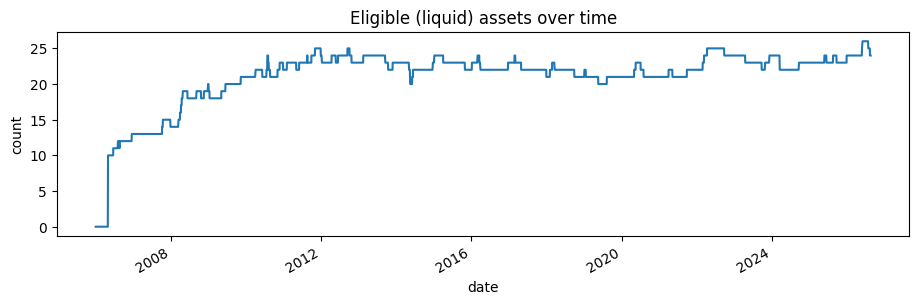

In [7]:
if volume_all is None:
    print("No volume matrix in the library — running WITHOUT the liquidity screen (documented deviation).")
    eligible = None
else:
    vol_shares = volume_all[TRADED].copy()
    spy_median = vol_shares["SPY"].tail(750).median()
    multiplier = 100 if spy_median < 5_000_000 else 1
    print(f"SPY median daily volume as stored: {spy_median:,.0f} -> unit multiplier {multiplier}")
    dollar_vol = (vol_shares * multiplier) * close
    adv63 = dollar_vol.rolling(63, min_periods=63).median()
    passing = (adv63 >= 25_000_000).astype(float)
    # Hysteresis: eligible only if the screen passed on EACH of the last 21 days.
    # Stays eligible while passing; one failing day drops it; needs 21 clean days to re-qualify.
    eligible = (passing.rolling(21, min_periods=21).sum() >= 21).where(close.notna(), False).astype(bool)
    coverage = eligible.sum(axis=1)
    print("Eligible assets — median:", int(coverage.median()), "| min:", int(coverage.min()), "| max:", int(coverage.max()))
    ax = coverage.plot(figsize=(11,3), title="Eligible (liquid) assets over time"); ax.set_ylabel("count"); plt.show()

## 4. CPCV: the two baselines at $1M, base costs (1 bps slippage)
Both definitions are fixed. `signal='sign'` is B1, `signal='macd'` is B2. Same vol scaling, same band, same cap.

In [8]:
extra = {"eligible": eligible} if eligible is not None else None
opt = CPCVOptimizer(df=close, target_col="SPY", strategy_class=TSMOMBaselineStrategy,
                    param_grid={"signal": ["sign", "macd"]},
                    asset_class="STK", max_lookback_bars=MAX_LOOKBACK,
                    initial_capital=INITIAL_CAPITAL,
                    n_splits=N_SPLITS, n_test_splits=N_TEST_SPLITS,
                    holdout=vault, extra_data=extra)
base_results = opt.run(parallel=False)
base_results

🔒 Holdout 's3_tsmom_v1': fenced 251 rows >= 2025-08-15 00:00:00 (4935 rows remain for research).
🔒 Holdout 's3_tsmom_v1': fenced 251 rows >= 2025-08-15 00:00:00 (4935 rows remain for research).


📐 CPCV Calibrated: 7163 days of data.
   -> Splits: 12 | Test Blocks: 2
   -> Combinatorial Paths: 66
   -> Purge Window: 273 bars
   -> Capital Base: $1,000,000
   -> Extra data matrices: ['eligible']
   -> 🔒 Holdout 's3_tsmom_v1' ENFORCED (cutoff 2025-08-15 00:00:00)
🚀 Igniting CPU Cluster: Testing 2 Parameter Sets.
   -> Total Path Simulations: 132
✅ Optimization Complete.


,signal,Mean_Sharpe,Median_Sharpe,P5_Sharpe,Max_Sharpe,Win_Rate_Paths
0,sign,0.403014,0.365767,-0.147880,0.963881,86.363636
1,macd,0.236234,0.246885,-0.194579,0.744641,78.787879


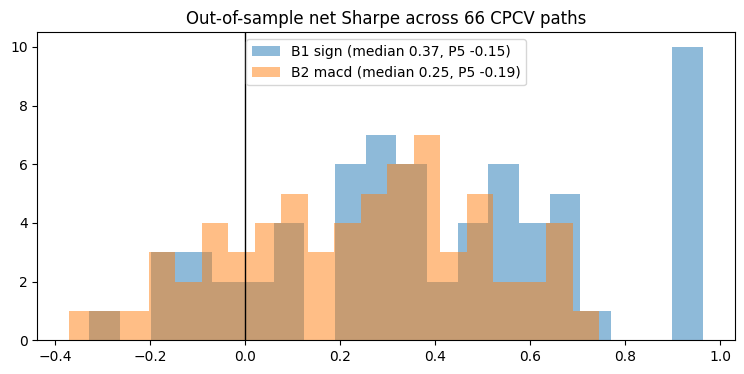

In [9]:
# Per-path distributions (the numbers behind P5)
paths = {k: v for k, v in opt.path_detail.items()}
fig, ax = plt.subplots(figsize=(9,4))
for k, v in paths.items():
    label = "B1 sign" if "'sign'" in k else "B2 macd"
    ax.hist(v, bins=20, alpha=0.5, label=f"{label} (median {np.median(v):.2f}, P5 {np.percentile(v,5):.2f})")
ax.axvline(0, color="k", lw=1); ax.set_title("Out-of-sample net Sharpe across 66 CPCV paths"); ax.legend(); plt.show()

## 5. Cost-sensitivity battery (charter §7.4)
Same two baselines, same 66 paths, slippage at 2 and 5 bps. If the answer flips sign between 1 and 5 bps,
the edge is a rounding error on the friction assumption, not an alpha.

In [10]:
sens_rows = []
for slip in [1.0, 2.0, 5.0]:
    o = CPCVOptimizer(df=close, target_col="SPY", strategy_class=TSMOMBaselineStrategy,
                      param_grid={"signal": ["sign", "macd"]}, asset_class="STK",
                      max_lookback_bars=MAX_LOOKBACK, initial_capital=INITIAL_CAPITAL,
                      n_splits=N_SPLITS, n_test_splits=N_TEST_SPLITS,
                      holdout=vault, extra_data=extra, slippage_bps=slip)
    r = o.run(parallel=False)
    for _, row in r.iterrows():
        sens_rows.append({"slippage_bps": slip, "signal": row["signal"],
                          "P5_Sharpe": row["P5_Sharpe"], "Median_Sharpe": row["Median_Sharpe"],
                          "Win_Rate_Paths": row["Win_Rate_Paths"]})
sens = pd.DataFrame(sens_rows).pivot(index="signal", columns="slippage_bps", values=["P5_Sharpe","Median_Sharpe","Win_Rate_Paths"]).round(3)
sens

🔒 Holdout 's3_tsmom_v1': fenced 251 rows >= 2025-08-15 00:00:00 (4935 rows remain for research).
🔒 Holdout 's3_tsmom_v1': fenced 251 rows >= 2025-08-15 00:00:00 (4935 rows remain for research).


📐 CPCV Calibrated: 7163 days of data.
   -> Splits: 12 | Test Blocks: 2
   -> Combinatorial Paths: 66
   -> Purge Window: 273 bars
   -> Capital Base: $1,000,000
   -> Slippage override: 1.0 bps
   -> Extra data matrices: ['eligible']
   -> 🔒 Holdout 's3_tsmom_v1' ENFORCED (cutoff 2025-08-15 00:00:00)
🚀 Igniting CPU Cluster: Testing 2 Parameter Sets.
   -> Total Path Simulations: 132


🔒 Holdout 's3_tsmom_v1': fenced 251 rows >= 2025-08-15 00:00:00 (4935 rows remain for research).
🔒 Holdout 's3_tsmom_v1': fenced 251 rows >= 2025-08-15 00:00:00 (4935 rows remain for research).


✅ Optimization Complete.
📐 CPCV Calibrated: 7163 days of data.
   -> Splits: 12 | Test Blocks: 2
   -> Combinatorial Paths: 66
   -> Purge Window: 273 bars
   -> Capital Base: $1,000,000
   -> Slippage override: 2.0 bps
   -> Extra data matrices: ['eligible']
   -> 🔒 Holdout 's3_tsmom_v1' ENFORCED (cutoff 2025-08-15 00:00:00)
🚀 Igniting CPU Cluster: Testing 2 Parameter Sets.
   -> Total Path Simulations: 132


🔒 Holdout 's3_tsmom_v1': fenced 251 rows >= 2025-08-15 00:00:00 (4935 rows remain for research).
🔒 Holdout 's3_tsmom_v1': fenced 251 rows >= 2025-08-15 00:00:00 (4935 rows remain for research).


✅ Optimization Complete.
📐 CPCV Calibrated: 7163 days of data.
   -> Splits: 12 | Test Blocks: 2
   -> Combinatorial Paths: 66
   -> Purge Window: 273 bars
   -> Capital Base: $1,000,000
   -> Slippage override: 5.0 bps
   -> Extra data matrices: ['eligible']
   -> 🔒 Holdout 's3_tsmom_v1' ENFORCED (cutoff 2025-08-15 00:00:00)
🚀 Igniting CPU Cluster: Testing 2 Parameter Sets.
   -> Total Path Simulations: 132
✅ Optimization Complete.


P5_Sharpe               Median_Sharpe                \
slippage_bps       1.0    2.0    5.0           1.0    2.0    5.0   
signal                                                             
macd            -0.195 -0.229 -0.321         0.247  0.224  0.127   
sign            -0.148 -0.173 -0.270         0.366  0.354  0.318   

             Win_Rate_Paths                  
slippage_bps            1.0     2.0     5.0  
signal                                       
macd                 78.788  77.273  60.606  
sign                 86.364  84.848  81.818

## 6. Full-sample diagnostics (fenced sample, base costs)
CPCV answers "is it robust across eras". This section answers the qualitative questions the charter
also asks: crisis behaviour (H3), cost drag (K4), turnover, drawdowns, and how the two baselines differ.

In [11]:
def run_full(signal):
    strat = TSMOMBaselineStrategy(instruments={}, params={"signal": signal})
    close_r = vault.enforce(close)
    dd = {"close": close_r}
    if eligible is not None:
        dd["eligible"] = vault.enforce(eligible)
    w = strat.generate_signals(dd)
    eng = PortfolioVectorEngine(prices=close_r, signals=w, asset_class="STK",
                                initial_capital=INITIAL_CAPITAL, execution_delay=1)
    res = eng.run()
    return w, res

CRISIS = {"GFC 2008H2": ("2008-07-01","2008-12-31"),
          "COVID 2020": ("2020-02-19","2020-04-30"),
          "Rates 2022": ("2022-01-01","2022-12-31")}

def summarize(name, w, res):
    net, gross = res["net_returns"], res["gross_returns"]
    ann = 252
    def sharpe(x): return (x.mean()/x.std())*np.sqrt(ann) if x.std() > 0 else np.nan
    eq = res["net_equity"]; dd = (eq/eq.cummax()-1).min()
    turnover = w.diff().abs().sum(axis=1).mean()*ann          # annualized sum |Δw|
    gross_pnl = res["gross_equity"].iloc[-1] - INITIAL_CAPITAL
    costs = res["cumulative_costs"].iloc[-1]
    row = {"strategy": name,
           "net_Sharpe": sharpe(net), "gross_Sharpe": sharpe(gross),
           "net_CAGR": (eq.iloc[-1]/INITIAL_CAPITAL)**(ann/len(eq))-1,
           "ann_vol": net.std()*np.sqrt(ann), "max_DD": dd,
           "turnover_x_NAV_per_yr": turnover,
           "cost_drag_pct_of_gross_pnl": costs/gross_pnl if gross_pnl > 0 else np.nan,
           "avg_gross_exposure": w.abs().sum(axis=1).mean()}
    for cname, (a, b) in CRISIS.items():
        row[f"ret_{cname}"] = (1+net.loc[a:b]).prod()-1
    return row

runs = {}
rows = []
for sig, name in [("sign","B1 sign"), ("macd","B2 macd")]:
    w, res = run_full(sig); runs[name] = (w, res); rows.append(summarize(name, w, res))
# SPY buy-and-hold for context (fenced sample)
spy = vault.enforce(close)["SPY"].pct_change().fillna(0)
rows.append({"strategy": "SPY (context)",
             "net_Sharpe": (spy.mean()/spy.std())*np.sqrt(252), "ann_vol": spy.std()*np.sqrt(252),
             "max_DD": ((1+spy).cumprod()/(1+spy).cumprod().cummax()-1).min(),
             **{f"ret_{c}": (1+spy.loc[a:b]).prod()-1 for c,(a,b) in CRISIS.items()}})
diag = pd.DataFrame(rows).set_index("strategy").round(3)
diag.T

🔒 Holdout 's3_tsmom_v1': fenced 251 rows >= 2025-08-15 00:00:00 (4935 rows remain for research).
🔒 Holdout 's3_tsmom_v1': fenced 251 rows >= 2025-08-15 00:00:00 (4935 rows remain for research).


🔒 Holdout 's3_tsmom_v1': fenced 251 rows >= 2025-08-15 00:00:00 (4935 rows remain for research).
🔒 Holdout 's3_tsmom_v1': fenced 251 rows >= 2025-08-15 00:00:00 (4935 rows remain for research).
🔒 Holdout 's3_tsmom_v1': fenced 251 rows >= 2025-08-15 00:00:00 (4935 rows remain for research).


strategy,B1 sign,B2 macd,SPY (context)
net_Sharpe,0.388,0.254,0.616
gross_Sharpe,0.456,0.338,NaN
net_CAGR,0.018,0.008,NaN
ann_vol,0.050,0.034,0.195
max_DD,-0.123,-0.076,-0.554
turnover_x_NAV_per_yr,11.006,9.419,NaN
cost_drag_pct_of_gross_pnl,0.162,0.266,NaN
avg_gross_exposure,0.895,0.521,NaN
ret_GFC 2008H2,-0.026,0.054,-0.285
ret_COVID 2020,-0.054,-0.003,-0.132


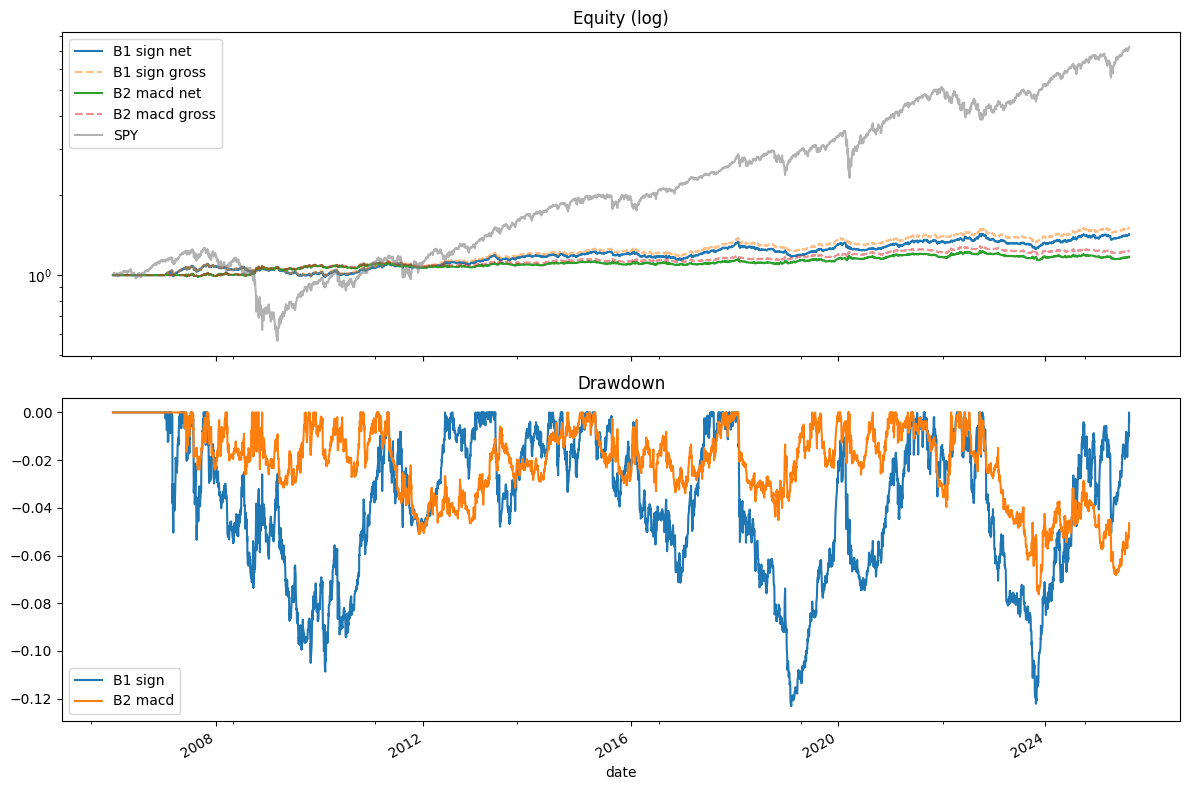

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(12,8), sharex=True)
for name, (w, res) in runs.items():
    (res["net_equity"]/INITIAL_CAPITAL).plot(ax=axes[0], label=f"{name} net")
    (res["gross_equity"]/INITIAL_CAPITAL).plot(ax=axes[0], ls="--", alpha=0.5, label=f"{name} gross")
    eq = res["net_equity"]; (eq/eq.cummax()-1).plot(ax=axes[1], label=name)
((1+spy).cumprod()).plot(ax=axes[0], color="gray", alpha=0.6, label="SPY")
axes[0].set_yscale("log"); axes[0].set_title("Equity (log)"); axes[0].legend()
axes[1].set_title("Drawdown"); axes[1].legend(); plt.tight_layout(); plt.show()

In [13]:
# Calendar-year net returns — where does each baseline earn, and where does it bleed?
yearly = pd.DataFrame({name: (1+res["net_returns"]).groupby(res.index.year).prod()-1 for name,(w,res) in runs.items()})
yearly["SPY"] = (1+spy).groupby(spy.index.year).prod()-1
(yearly*100).round(1)

,B1 sign,B2 macd,SPY
date,,,
2006,0.0,0.0,13.2
2007,7.8,-0.7,4.7
2008,-3.3,6.5,-36.9
2009,-2.8,2.3,26.4
2010,5.3,1.6,15.1
2011,0.1,-2.9,1.9
2012,4.7,0.8,16.1
2013,6.0,2.2,32.2
2014,0.1,1.6,13.5


In [14]:
# 6b — Per-era Sharpe (12 equal blocks, same geometry as CPCV) and correlation to SPY
close_r = vault.enforce(close)
blocks = np.array_split(np.arange(len(close_r)), N_SPLITS)
rows = []
for i, idx in enumerate(blocks, 1):
    row = {"block": i, "from": close_r.index[idx[0]].date(), "to": close_r.index[idx[-1]].date()}
    for name, (w, res) in runs.items():
        r = res["net_returns"].iloc[idx]
        row[name] = (r.mean()/r.std())*np.sqrt(252) if r.std() > 0 else np.nan
    s = spy.iloc[idx]
    row["SPY"] = (s.mean()/s.std())*np.sqrt(252) if s.std() > 0 else np.nan
    rows.append(row)
per_block = pd.DataFrame(rows).set_index("block").round(2)
print("Correlation of net daily returns to SPY:",
      {name: round(res["net_returns"].corr(spy), 3) for name, (w, res) in runs.items()})
per_block

🔒 Holdout 's3_tsmom_v1': fenced 251 rows >= 2025-08-15 00:00:00 (4935 rows remain for research).


Correlation of net daily returns to SPY: {'B1 sign': np.float64(0.065), 'B2 macd': np.float64(-0.2)}


,from,to,B1 sign,B2 macd,SPY
block,,,,,
1,2006-01-03,2007-08-22,0.51,-0.33,0.96
2,2007-08-23,2009-04-13,-0.04,0.75,-0.65
3,2009-04-14,2010-11-29,0.13,0.56,1.25
4,2010-11-30,2012-07-17,0.95,-0.10,0.63
5,2012-07-18,2014-03-07,0.96,0.42,1.93
6,2014-03-10,2015-10-22,0.08,0.08,0.62
7,2015-10-23,2017-06-12,0.32,0.12,1.09
8,2017-06-13,2019-01-30,-0.37,0.20,0.62
9,2019-01-31,2020-09-16,0.91,0.75,0.74


## 7. Gate K1 verdict
Pre-registered: **best baseline net P5_Sharpe > 0 at base costs** to pass. Recorded regardless of outcome.

In [15]:
best = base_results.iloc[0]
k1_pass = bool(best["P5_Sharpe"] > 0)
verdict = {
    "study_id": STUDY_ID, "phase": 1, "gate": "K1",
    "best_baseline": best["signal"], "P5_Sharpe": float(best["P5_Sharpe"]),
    "Median_Sharpe": float(best["Median_Sharpe"]), "Win_Rate_Paths": float(best["Win_Rate_Paths"]),
    "n_paths": len(opt.paths), "capital": INITIAL_CAPITAL, "research_start": RESEARCH_START,
    "holdout_cutoff": HOLDOUT_CUTOFF, "liquidity_screen": eligible is not None,
    "K1_PASS": k1_pass,
    "sensitivity": {f"{s}bps": sens["P5_Sharpe"][s].to_dict() for s in [1.0,2.0,5.0]},
    "diagnostics": diag.to_dict(),
    "path_sharpes": {k: v.tolist() for k, v in opt.path_detail.items()},
}
out = RESULTS_DIR / "s3_phase1_baseline_results.json"
out.write_text(json.dumps(verdict, indent=2, default=str))
print("K1:", "PASS ✅ — proceed to Phase 2 (features)" if k1_pass else "FAIL ❌ — strategy class dead at this cost structure; stop.")
print("Best baseline:", best["signal"], "| P5", round(best["P5_Sharpe"],3), "| median", round(best["Median_Sharpe"],3), "| win-rate", round(best["Win_Rate_Paths"],1), "%")
print("Saved:", out)

K1: FAIL ❌ — strategy class dead at this cost structure; stop.
Best baseline: sign | P5 -0.148 | median 0.366 | win-rate 86.4 %
Saved: c:\Users\7325\Documents\Bluegrey\research\results\s3_phase1_baseline_results.json


In [16]:
# 8 — Amendment A3: placebo significance test. Run ONLY after A3 is logged in the charter.
# Null: identical machinery, costs, sizing and CPCV slices, but each asset's signal DIRECTION is
# multiplied by a random ±1 redrawn every 252 bars. Pass iff the real baseline's median path Sharpe
# AND win-rate both exceed the 95th percentile of the null. Fail -> the study stops. No further appeals.
rng = np.random.default_rng(20260819)
N_DRAWS = 200           # reduce to 100 if runtime is painful; record whichever you used
close_r = vault.enforce(close)
elig_r  = vault.enforce(eligible) if eligible is not None else None

def path_stats(net):
    sh = []
    for tr, te in opt.paths:
        r = net.iloc[te]
        sh.append((r.mean()/r.std())*np.sqrt(opt.bars_per_year) if r.std() > 0 else 0.0)
    sh = np.array(sh)
    return float(np.median(sh)), float((sh > 0).mean())

class PlaceboTSMOM(TSMOMBaselineStrategy):
    def generate_signals(self, data):
        c = data["close"]
        n_blocks = int(np.ceil(len(c) / 252))
        flips = np.repeat(rng.choice([-1.0, 1.0], size=(n_blocks, c.shape[1])), 252, axis=0)[:len(c)]
        self._flips = pd.DataFrame(flips, index=c.index, columns=c.columns)
        return super().generate_signals(data)
    def _sign_conviction(self, c):  return super()._sign_conviction(c) * self._flips
    def _macd_conviction(self, c):  return super()._macd_conviction(c) * self._flips

null = {"sign": [], "macd": []}
for d in range(N_DRAWS):
    for sig in ["sign", "macd"]:
        s = PlaceboTSMOM(instruments={}, params={"signal": sig})
        dd = {"close": close_r}
        if elig_r is not None: dd["eligible"] = elig_r
        w = s.generate_signals(dd)
        res = PortfolioVectorEngine(prices=close_r, signals=w, asset_class="STK",
                                    initial_capital=INITIAL_CAPITAL, execution_delay=1).run()
        null[sig].append(path_stats(res["net_returns"]))
    if (d+1) % 25 == 0: print(f"  {d+1}/{N_DRAWS} placebo draws done")

report = {}
for sig in ["sign", "macd"]:
    obs = opt.path_detail[repr({"signal": sig})]
    obs_med, obs_win = float(np.median(obs)), float((obs > 0).mean())
    nm = np.array([m for m, w_ in null[sig]]); nw = np.array([w_ for m, w_ in null[sig]])
    p_med, p_win = float((nm >= obs_med).mean()), float((nw >= obs_win).mean())
    passed = (p_med < 0.05) and (p_win < 0.05)
    report[sig] = {"obs_median": obs_med, "null95_median": float(np.percentile(nm, 95)), "p_median": p_med,
                   "obs_winrate": obs_win, "null95_winrate": float(np.percentile(nw, 95)), "p_winrate": p_win,
                   "PASS": passed}
    print(f"{sig:>5}: median {obs_med:.3f} vs null95 {np.percentile(nm,95):.3f} (p={p_med:.3f}) | "
          f"win-rate {obs_win:.2f} vs null95 {np.percentile(nw,95):.2f} (p={p_win:.3f}) -> {'PASS' if passed else 'FAIL'}")
k1_prime = any(v["PASS"] for v in report.values())
print("\nK1' (A3):", "PASS ✅ — proceed to Phase 2" if k1_prime else "FAIL ❌ — study stops. No further appeals.")
(RESULTS_DIR / "s3_phase1_placebo_results.json").write_text(json.dumps({"n_draws": N_DRAWS, "report": report, "K1_prime_pass": k1_prime}, indent=2))

🔒 Holdout 's3_tsmom_v1': fenced 251 rows >= 2025-08-15 00:00:00 (4935 rows remain for research).
🔒 Holdout 's3_tsmom_v1': fenced 251 rows >= 2025-08-15 00:00:00 (4935 rows remain for research).


  25/200 placebo draws done
  50/200 placebo draws done
  75/200 placebo draws done
  100/200 placebo draws done
  125/200 placebo draws done
  150/200 placebo draws done
  175/200 placebo draws done
  200/200 placebo draws done
 sign: median 0.366 vs null95 0.278 (p=0.005) | win-rate 0.86 vs null95 0.70 (p=0.000) -> PASS
 macd: median 0.247 vs null95 0.151 (p=0.030) | win-rate 0.79 vs null95 0.65 (p=0.010) -> PASS

K1' (A3): PASS ✅ — proceed to Phase 2


578

In [17]:
# 8b — Sanity check on the placebo machinery (diagnostic only, no decisions)
import time
t0 = time.time()
s = PlaceboTSMOM(instruments={}, params={"signal": "sign"})
dd = {"close": close_r, **({"eligible": elig_r} if elig_r is not None else {})}
w_pl = s.generate_signals(dd)
res_pl = PortfolioVectorEngine(prices=close_r, signals=w_pl, asset_class="STK",
                               initial_capital=INITIAL_CAPITAL, execution_delay=1).run()
dt = time.time() - t0
print(f"One full placebo backtest: {dt:.2f}s  ->  400 of them ≈ {dt*400:.0f}s")
w_real = runs["B1 sign"][0]
mask = (w_real.values != 0)
flipped = (np.sign(w_pl.values) != np.sign(w_real.values))[mask].mean()
print(f"Share of held asset-days where the placebo points the OPPOSITE way to the real strategy: {flipped:.2f}  (expect ≈ 0.5)")
nm = np.array([m for m, _ in null["sign"]])
print(f"Null medians (sign): mean {nm.mean():.3f} | std {nm.std():.3f} | min {nm.min():.3f} | max {nm.max():.3f}  (expect mean ≈ 0, spread real)")

One full placebo backtest: 0.20s  ->  400 of them ≈ 80s
Share of held asset-days where the placebo points the OPPOSITE way to the real strategy: 0.51  (expect ≈ 0.5)
Null medians (sign): mean -0.159 | std 0.244 | min -0.785 | max 0.448  (expect mean ≈ 0, spread real)


In [18]:
# 8c — Why is the null mean negative? Separate costs from structure (diagnostic only).
gross_meds, net_meds, turns = [], [], []
real_turn = runs["B1 sign"][0].diff().abs().sum(axis=1).mean() * 252
for d in range(100):
    s = PlaceboTSMOM(instruments={}, params={"signal": "sign"})
    w = s.generate_signals({"close": close_r, **({"eligible": elig_r} if elig_r is not None else {})})
    res = PortfolioVectorEngine(prices=close_r, signals=w, asset_class="STK",
                                initial_capital=INITIAL_CAPITAL, execution_delay=1).run()
    gross_meds.append(path_stats(res["gross_returns"])[0]); net_meds.append(path_stats(res["net_returns"])[0])
    turns.append(w.diff().abs().sum(axis=1).mean() * 252)
gross_meds, net_meds = np.array(gross_meds), np.array(net_meds)
print(f"Placebo GROSS median Sharpe: mean {gross_meds.mean():+.3f} (std err {gross_meds.std()/10:.3f})  <- ≈0 means no structural bias")
print(f"Placebo NET   median Sharpe: mean {net_meds.mean():+.3f}   -> cost drag ≈ {gross_meds.mean()-net_meds.mean():.3f} Sharpe")
print(f"Turnover: placebo {np.mean(turns):.1f}x NAV/yr vs real B1 {real_turn:.1f}x")
print(f"Real B1: gross {diag.loc['B1 sign','gross_Sharpe']:.3f} / net {diag.loc['B1 sign','net_Sharpe']:.3f} -> cost drag {diag.loc['B1 sign','gross_Sharpe']-diag.loc['B1 sign','net_Sharpe']:.3f}")

Placebo GROSS median Sharpe: mean +0.019 (std err 0.023)  <- ≈0 means no structural bias
Placebo NET   median Sharpe: mean -0.159   -> cost drag ≈ 0.178 Sharpe
Turnover: placebo 11.9x NAV/yr vs real B1 11.0x
Real B1: gross 0.456 / net 0.388 -> cost drag 0.068


In [19]:
# 8d — Fair K1' re-test on GROSS Sharpe. Direction information only: costs are identical in dollars on both
# sides and differ in Sharpe terms only through portfolio volatility. This RAISES the bar versus cell 8.
N_DRAWS_G = 200
null_g = {"sign": [], "macd": []}
dd = {"close": close_r, **({"eligible": elig_r} if elig_r is not None else {})}
for d in range(N_DRAWS_G):
    for sig in ["sign", "macd"]:
        w = PlaceboTSMOM(instruments={}, params={"signal": sig}).generate_signals(dd)
        res = PortfolioVectorEngine(prices=close_r, signals=w, asset_class="STK",
                                    initial_capital=INITIAL_CAPITAL, execution_delay=1).run()
        null_g[sig].append(path_stats(res["gross_returns"]))
report_g = {}
for sig, name in [("sign", "B1 sign"), ("macd", "B2 macd")]:
    obs_med, obs_win = path_stats(runs[name][1]["gross_returns"])
    nm = np.array([m for m, _ in null_g[sig]]); nw = np.array([w_ for _, w_ in null_g[sig]])
    p_med, p_win = float((nm >= obs_med).mean()), float((nw >= obs_win).mean())
    passed = (p_med < 0.05) and (p_win < 0.05)
    report_g[sig] = {"obs_gross_median": obs_med, "null95_gross_median": float(np.percentile(nm, 95)), "p_median": p_med,
                     "obs_gross_winrate": obs_win, "null95_gross_winrate": float(np.percentile(nw, 95)), "p_winrate": p_win,
                     "null_gross_mean": float(nm.mean()), "PASS": passed}
    print(f"{sig:>5} GROSS: median {obs_med:.3f} vs null95 {np.percentile(nm,95):.3f} (p={p_med:.3f}) | "
          f"win-rate {obs_win:.2f} vs null95 {np.percentile(nw,95):.2f} (p={p_win:.3f}) -> {'PASS' if passed else 'FAIL'}")
k1_fair = any(v["PASS"] for v in report_g.values())
print("\nK1' FAIR (gross) verdict:", "PASS ✅" if k1_fair else "FAIL ❌ — study stops.")
print("Net-test (cell 8) was biased toward PASS by cost-on-lower-vol; this gross test supersedes it for the record.")
(RESULTS_DIR / "s3_phase1_placebo_gross_results.json").write_text(
    json.dumps({"n_draws": N_DRAWS_G, "report": report_g, "K1_fair_pass": k1_fair}, indent=2))

 sign GROSS: median 0.406 vs null95 0.513 (p=0.085) | win-rate 0.89 vs null95 0.82 (p=0.025) -> FAIL
 macd GROSS: median 0.345 vs null95 0.376 (p=0.065) | win-rate 0.86 vs null95 0.79 (p=0.005) -> FAIL

K1' FAIR (gross) verdict: FAIL ❌ — study stops.
Net-test (cell 8) was biased toward PASS by cost-on-lower-vol; this gross test supersedes it for the record.


726